In [28]:
# =========================================================
#  - import
#  - 경로 설정
#  - load_trajectory 정의
#  - traj_dict 생성 (1~16)
#  - clean/noisy 그룹 정의
#  - extract_features 정의
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

# ---------------------------------------------------------
# 1. 경로 설정 (필요하면 여기만 수정)
# ---------------------------------------------------------
base_dir = Path().resolve()

# 너가 쓰는 구조에 맞게:
#   ./data/circle/1.txt ~ 16.txt
data_dir = base_dir / "data" / "circle"

print(f"[INFO] base_dir : {base_dir}")
print(f"[INFO] data_dir : {data_dir}")

# ---------------------------------------------------------
# 2. 궤적 로딩 함수
# ---------------------------------------------------------
def load_trajectory(idx: int):
    """
    idx: 1~16 정수
    반환: xs, ys, zs (numpy array)
    """
    file_path = data_dir / f"{idx}.txt"
    xs, ys, zs = [], [], []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cols = line.split(",")
            if len(cols) <= 6:
                continue
            xyz_str = cols[6].strip()
            parts = xyz_str.split("/")
            if len(parts) != 3:
                continue
            try:
                x, y, z = map(float, parts)
            except ValueError:
                # 숫자 변환 안 되면 스킵
                continue
            xs.append(x)
            ys.append(y)
            zs.append(z)

    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)
    zs = np.array(zs, dtype=float)
    return xs, ys, zs

# ---------------------------------------------------------
# 3. 원본 궤적 전체 로딩 (1~16)
# ---------------------------------------------------------
traj_dict = {}
for idx in range(1, 17):
    xs, ys, zs = load_trajectory(idx)
    traj_dict[idx] = (xs, ys, zs)

print(f"[INFO] Loaded trajectories: {len(traj_dict)} files")

# ---------------------------------------------------------
# 4. clean / noisy 그룹 ID 정의
# ---------------------------------------------------------
group_clean_ids = list(range(1, 9))   # 1~8
group_noisy_ids = list(range(9, 17))  # 9~16

print(f"[INFO] clean ids : {group_clean_ids}")
print(f"[INFO] noisy ids : {group_noisy_ids}")

# ---------------------------------------------------------
# 5. feature 추출 함수 (PCA 전/후 공통으로 사용)
# ---------------------------------------------------------
def extract_features(xs, ys, zs):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    zs = np.asarray(zs, dtype=float)

    # 중심 (평균 위치)
    cx, cy, cz = xs.mean(), ys.mean(), zs.mean()

    # 공분산 행렬 (3x3)
    coords = np.vstack([xs, ys, zs])  # (3, N)
    cov = np.cov(coords)              # (3, 3)

    cov_xx, cov_xy, cov_xz = cov[0, 0], cov[0, 1], cov[0, 2]
    cov_yx, cov_yy, cov_yz = cov[1, 0], cov[1, 1], cov[1, 2]
    cov_zx, cov_zy, cov_zz = cov[2, 0], cov[2, 1], cov[2, 2]

    # 각 축 분산
    var_x, var_y, var_z = cov_xx, cov_yy, cov_zz

    # bounding box
    x_range = xs.max() - xs.min() if len(xs) > 0 else 0.0
    y_range = ys.max() - ys.min() if len(ys) > 0 else 0.0
    z_range = zs.max() - zs.min() if len(zs) > 0 else 0.0
    bbox_volume = x_range * y_range * z_range

    # path length
    if len(xs) >= 2:
        diffs = np.stack([np.diff(xs), np.diff(ys), np.diff(zs)], axis=1)
        segment_lengths = np.linalg.norm(diffs, axis=1)
        path_length = segment_lengths.sum()
    else:
        path_length = 0.0

    # 중심 기준 반지름
    centered = np.stack([xs - cx, ys - cy, zs - cz], axis=1)
    radii = np.linalg.norm(centered, axis=1)
    radius_mean = radii.mean() if len(radii) > 0 else 0.0
    radius_std = radii.std(ddof=1) if len(radii) > 1 else 0.0

    return {
        "center_x": cx,
        "center_y": cy,
        "center_z": cz,
        "var_x": var_x,
        "var_y": var_y,
        "var_z": var_z,
        "cov_xy": cov_xy,
        "cov_xz": cov_xz,
        "cov_yz": cov_yz,
        "x_range": x_range,
        "y_range": y_range,
        "z_range": z_range,
        "bbox_volume": bbox_volume,
        "path_length": path_length,
        "radius_mean": radius_mean,
        "radius_std": radius_std,
    }

print("[INFO] Setup done. You can now run normalize_and_pca and later cells.")

[INFO] base_dir : /Users/panwoo/Desktop/ML-Trajectory
[INFO] data_dir : /Users/panwoo/Desktop/ML-Trajectory/data/circle
[INFO] Loaded trajectories: 16 files
[INFO] clean ids : [1, 2, 3, 4, 5, 6, 7, 8]
[INFO] noisy ids : [9, 10, 11, 12, 13, 14, 15, 16]
[INFO] Setup done. You can now run normalize_and_pca and later cells.


In [29]:
# =========================================================
# 셀 A. 정규화 + PCA 정렬 함수 정의
#   - 1) 중심 이동
#   - 2) 스케일 정규화 (평균 반지름으로 나눔)
#   - 3) PCA 회전 정렬
# =========================================================
import numpy as np

def normalize_and_pca(xs, ys, zs, eps=1e-8):
    """
    입력: 원본 xs, ys, zs (1D numpy array)
    출력:
    xn, yn, zn : 정규화 + PCA 정렬된 궤적
    center     : 원본 좌표 중심 (3,)
    scale      : 사용한 스케일 값 (scalar)
    eigvecs    : PCA 회전에 사용된 3x3 행렬 (열벡터 = 주성분)
    """
    coords = np.stack([xs, ys, zs], axis=1)  # (N, 3)

    # 1) 중심 이동
    center = coords.mean(axis=0, keepdims=True)  # (1,3)
    coords_centered = coords - center

    # 2) 스케일 정규화: 중심 기준 반지름 평균으로 나눔
    radii = np.linalg.norm(coords_centered, axis=1)  # (N,)
    scale = radii.mean()
    if scale < eps:
        scale = 1.0
    coords_scaled = coords_centered / scale

    # 3) PCA 회전 정렬: 공분산 → 고유분해
    # rowvar=False: 각 열이 변수(x,y,z), 각 행이 샘플
    cov = np.cov(coords_scaled, rowvar=False)  # (3,3)
    eigvals, eigvecs = np.linalg.eigh(cov)     # 오름차순
    order = np.argsort(eigvals)[::-1]          # 내림차순 정렬
    eigvecs = eigvecs[:, order]                # 열: 주성분 1,2,3

    # 좌표 회전
    coords_aligned = coords_scaled @ eigvecs   # (N,3)

    xn, yn, zn = coords_aligned[:, 0], coords_aligned[:, 1], coords_aligned[:, 2]
    return xn, yn, zn, center.ravel(), scale, eigvecs

In [30]:
# =========================================================
# 셀 B. 모든 궤적(1~16)에 대해 정규화 + PCA 적용
# =========================================================
norm_traj_dict = {}     # key: idx, value: (xn, yn, zn)
norm_meta_dict = {}     # key: idx, value: dict(center, scale, eigvecs)

for idx in range(1, 17):
    xs, ys, zs = traj_dict[idx]   # 앞에서 만든 원본 traj_dict 사용
    xn, yn, zn, center, scale, eigvecs = normalize_and_pca(xs, ys, zs)
    norm_traj_dict[idx] = (xn, yn, zn)
    norm_meta_dict[idx] = {
        "center": center,
        "scale": scale,
        "eigvecs": eigvecs,
    }

print("정규화 + PCA 정렬 완료. 총 궤적:", len(norm_traj_dict))

정규화 + PCA 정렬 완료. 총 궤적: 16


In [31]:
# =========================================================
# 셀 C. 정규화된 궤적 시각화 함수 (3D + 투영)
#  - 스케일이 1 근처라 margin을 작게 잡음
# =========================================================
def get_limits_norm(xs, ys, zs, margin=0.5):
    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()
    zmin, zmax = zs.min(), zs.max()
    return (
        xmin - margin, xmax + margin,
        ymin - margin, ymax + margin,
        zmin - margin, zmax + margin,
    )

def plot_3d_norm(xs, ys, zs, title, save_path, margin=0.5):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)
    ax.set_xlabel("X'")
    ax.set_ylabel("Y'")
    ax.set_zlabel("Z'")

    xmin, xmax, ymin, ymax, zmin, zmax = get_limits_norm(xs, ys, zs, margin)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    ax.plot(xs, ys, zs, "-o", markersize=2)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)

def plot_projection_norm(u, v, xlabel, ylabel, title, save_path, margin=0.5):
    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    umin, umax = u.min(), u.max()
    vmin, vmax = v.min(), v.max()
    ax.set_xlim(umin - margin, umax + margin)
    ax.set_ylim(vmin - margin, vmax + margin)

    ax.plot(u, v, "-o", markersize=2)
    ax.set_aspect("equal", adjustable="box")

    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)

In [32]:
from pathlib import Path
base_dir = Path().resolve()
out_root = base_dir / "outputs" / "circle"

out_root.mkdir(parents=True, exist_ok=True)

print("[INFO] out_root :", out_root)

[INFO] out_root : /Users/panwoo/Desktop/ML-Trajectory/outputs/circle


In [33]:
# =========================================================
# 셀 D. 정규화된 궤적 1~16 개별 시각화 저장
#   (원본과 구분되게 폴더 새로 사용)
# =========================================================
out_norm_individual = out_root / "normalized_individual"
out_norm_group = out_root / "normalized_group"
out_norm_features = out_root / "normalized_features"

for p in [out_norm_individual, out_norm_group, out_norm_features]:
    p.mkdir(parents=True, exist_ok=True)

for idx in range(1, 17):
    xn, yn, zn = norm_traj_dict[idx]

    # 3D
    save3d = out_norm_individual / f"circle_norm_{idx:02d}_3d.png"
    plot_3d_norm(xn, yn, zn,title=f"Normalized Trajectory {idx} - 3D",save_path=save3d)

    # XY'
    savexy = out_norm_individual / f"circle_norm_{idx:02d}_xy.png"
    plot_projection_norm(xn, yn,xlabel="X'", ylabel="Y'",title=f"Normalized Trajectory {idx} - XY'",save_path=savexy)

    # Y'Z'
    saveyz = out_norm_individual / f"circle_norm_{idx:02d}_yz.png"
    plot_projection_norm(yn, zn,xlabel="Y'", ylabel="Z'",title=f"Normalized Trajectory {idx} - YZ'",save_path=saveyz)

    # X'Z'
    savexz = out_norm_individual / f"circle_norm_{idx:02d}_xz.png"
    plot_projection_norm(xn, zn,xlabel="X'", ylabel="Z'",title=f"Normalized Trajectory {idx} - XZ'",save_path=savexz)

print("정규화된 개별 궤적 그림 저장 완료.")

정규화된 개별 궤적 그림 저장 완료.


In [34]:
# =========================================================
# 셀 E. 정규화된 궤적 그룹 비교 (3D + 평면)
# =========================================================
def plot_group_3d_norm(traj_dict_norm, clean_ids, noisy_ids,title, save_path, margin=0.5):
    all_x, all_y, all_z = [], [], []
    for idx in clean_ids + noisy_ids:
        xs, ys, zs = traj_dict_norm[idx]
        all_x.append(xs)
        all_y.append(ys)
        all_z.append(zs)
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    all_z = np.concatenate(all_z)

    xmin, xmax = all_x.min() - margin, all_x.max() + margin
    ymin, ymax = all_y.min() - margin, all_y.max() + margin
    zmin, zmax = all_z.min() - margin, all_z.max() + margin

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)
    ax.set_xlabel("X'")
    ax.set_ylabel("Y'")
    ax.set_zlabel("Z'")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

    for idx in clean_ids:
        xs, ys, zs = traj_dict_norm[idx]
        ax.plot(xs, ys, zs, alpha=0.7, linewidth=1,
                label="clean" if idx == clean_ids[0] else "")

    for idx in noisy_ids:
        xs, ys, zs = traj_dict_norm[idx]
        ax.plot(xs, ys, zs, alpha=0.7, linewidth=1, linestyle="--",
                label="noisy" if idx == noisy_ids[0] else "")

    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)

def plot_group_projection_norm(traj_dict_norm, clean_ids, noisy_ids,plane="xy", title="", save_path=None, margin=0.5):
    all_u, all_v = [], []

    def get_uv(xs, ys, zs):
        if plane == "xy":
            return xs, ys
        elif plane == "yz":
            return ys, zs
        elif plane == "xz":
            return xs, zs
        else:
            raise ValueError("plane must be 'xy', 'yz', or 'xz'")

    for idx in clean_ids + noisy_ids:
        xs, ys, zs = traj_dict_norm[idx]
        u, v = get_uv(xs, ys, zs)
        all_u.append(u)
        all_v.append(v)

    all_u = np.concatenate(all_u)
    all_v = np.concatenate(all_v)

    umin, umax = all_u.min() - margin, all_u.max() + margin
    vmin, vmax = all_v.min() - margin, all_v.max() + margin

    fig, ax = plt.subplots()
    ax.set_title(title)

    labels = {
        "xy": ("X'", "Y'"),
        "yz": ("Y'", "Z'"),
        "xz": ("X'", "Z'")
    }
    xlabel, ylabel = labels[plane]
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xlim(umin, umax)
    ax.set_ylim(vmin, vmax)

    for idx in clean_ids:
        xs, ys, zs = traj_dict_norm[idx]
        u, v = get_uv(xs, ys, zs)
        ax.plot(u, v, alpha=0.7, linewidth=1,
                label="clean" if idx == clean_ids[0] else "")

    for idx in noisy_ids:
        xs, ys, zs = traj_dict_norm[idx]
        u, v = get_uv(xs, ys, zs)
        ax.plot(u, v, alpha=0.7, linewidth=1, linestyle="--",
                label="noisy" if idx == noisy_ids[0] else "")

    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)

# 3D 그룹 비교
plot_group_3d_norm(
    norm_traj_dict, group_clean_ids, group_noisy_ids,
    title="Normalized Clean (1-8) vs Noisy (9-16) - 3D",
    save_path=out_norm_group / "group_norm_clean_vs_noisy_3d.png"
)

# XY', YZ', XZ' 그룹 비교
for plane in ["xy", "yz", "xz"]:
    plot_group_projection_norm(
        norm_traj_dict, group_clean_ids, group_noisy_ids,
        plane=plane,
        title=f"Normalized Clean vs Noisy - {plane.upper()}'",
        save_path=out_norm_group / f"group_norm_clean_vs_noisy_{plane}.png"
    )

print("정규화된 그룹 비교 그림 저장 완료.")

정규화된 그룹 비교 그림 저장 완료.


[INFO] out_norm_features : /Users/panwoo/Desktop/ML-Trajectory/outputs/circle/normalized_features
[INFO] Normalized feature table (df_features_norm):


file_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
feature,,,,,,,,,,,,,,,,
center_x,-3.681569e-17,-2.924044e-17,-5.057244e-17,-5.302558e-17,2.166289e-17,0.000000e+00,0.000000e+00,3.716228e-17,1.214603e-16,-1.032265e-16,3.588600e-17,1.164824e-16,5.753382e-17,-2.166289e-17,-5.707171e-17,5.329071e-17
center_y,1.104471e-16,-5.848088e-17,7.585866e-17,7.953837e-17,-5.776770e-17,6.932124e-17,-3.130144e-17,-2.972982e-17,1.417037e-16,0.000000e+00,3.588600e-17,-3.882747e-17,-8.630074e-17,-8.665155e-17,-2.853585e-17,-3.552714e-17
center_z,-3.727588e-16,-5.391206e-17,-2.576033e-16,3.314099e-17,1.098940e-16,1.218537e-17,8.901348e-17,4.540766e-16,-8.729959e-17,8.602212e-18,-9.868649e-17,8.250838e-17,-2.031663e-16,3.114040e-17,-3.566982e-16,-3.465284e-16
var_x,7.693870e-01,5.988793e-01,8.209198e-01,5.903338e-01,6.910290e-01,7.666194e-01,6.200335e-01,5.690699e-01,7.473979e-01,7.857338e-01,6.908498e-01,7.174441e-01,6.611117e-01,6.499313e-01,6.313624e-01,5.812727e-01
var_y,3.397165e-01,4.504361e-01,3.535293e-01,4.670773e-01,4.891196e-01,4.174067e-01,4.970988e-01,5.212959e-01,3.775430e-01,2.570168e-01,3.771346e-01,3.152543e-01,4.605771e-01,3.630947e-01,4.554033e-01,4.420443e-01
var_z,1.014412e-02,2.871482e-03,1.427761e-03,2.651192e-03,4.561819e-04,7.045047e-04,3.037302e-03,2.832858e-04,2.169879e-03,1.330762e-02,7.767499e-03,1.375843e-02,4.134618e-03,2.263017e-03,2.108211e-03,5.329847e-04
cov_xy,-3.379820e-16,1.468064e-17,-7.295751e-17,-1.663255e-17,2.030122e-16,5.224579e-17,-1.395148e-16,1.343463e-16,1.153839e-16,3.503131e-18,-8.642875e-17,2.494200e-17,1.444193e-16,7.876812e-17,1.862310e-16,3.570567e-17
cov_xz,1.915424e-17,-1.101048e-17,-1.376875e-16,1.717831e-17,-5.437827e-18,-2.782360e-17,5.772177e-18,5.831003e-19,-3.869920e-17,1.153338e-16,5.677596e-17,-2.676702e-17,-6.318342e-18,-4.260948e-17,-5.372047e-18,-4.463208e-18
cov_yz,3.397167e-18,-3.463712e-17,-1.349615e-16,6.536074e-18,2.141144e-17,1.360567e-19,1.326373e-17,-1.513145e-17,1.887379e-17,-7.679941e-18,3.724166e-17,-6.995926e-18,-4.693626e-17,-2.578743e-17,-5.372047e-18,1.143697e-17


=== [정규화 후] 그룹별 feature 평균 ===


,center_x,center_y,center_z,var_x,var_y,var_z,cov_xy,cov_xz,cov_yz,x_range,y_range,z_range,bbox_volume,path_length,radius_mean,radius_std
group,,,,,,,,,,,,,,,,
clean,-1.385362e-17,1.973568e-17,1.754525e-18,0.678284,0.441960,0.002697,-2.035023e-17,-1.740895e-17,-1.749820e-17,2.466818,2.179853,0.165145,0.874500,7.950466,1.0,0.335970
noisy,2.533651e-17,-1.228163e-17,-1.212660e-16,0.683138,0.381009,0.005755,6.281553e-17,5.985064e-18,-3.152398e-18,2.360632,2.052392,0.250973,1.186037,7.221246,1.0,0.243971


=== [정규화 후] 그룹별 feature 표준편차 ===


,center_x,center_y,center_z,var_x,var_y,var_z,cov_xy,cov_xz,cov_yz,x_range,y_range,z_range,bbox_volume,path_length,radius_mean,radius_std
group,,,,,,,,,,,,,,,,
clean,3.358276e-17,7.029495e-17,2.494631e-16,0.097080,0.066695,0.003208,1.682645e-16,5.092552e-17,5.054341e-17,0.248923,0.205033,0.090409,0.479360,0.692638,1.678499e-16,0.081287
noisy,8.018307e-17,7.435569e-17,1.674003e-16,0.066048,0.071351,0.005256,8.690686e-17,5.392748e-17,2.618411e-17,0.158259,0.163125,0.130327,0.529193,0.485241,2.967196e-16,0.089683


/var/folders/jl/ryr8b71j4pl_cl6lp9xzp4900000gn/T/ipykernel_44452/450305270.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/jl/ryr8b71j4pl_cl6lp9xzp4900000gn/T/ipykernel_44452/450305270.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/jl/ryr8b71j4pl_cl6lp9xzp4900000gn/T/ipykernel_44452/450305270.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/jl/ryr8b71j4pl_cl6lp9xzp4900000gn/T/ipykernel_44452/450305270.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; supp

ValueError: Too many bins for data range. Cannot create 5 finite-sized bins.

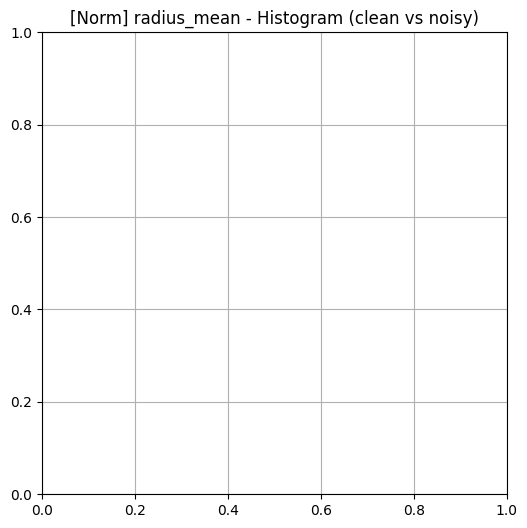

In [35]:
# =========================================================
# 셀 F.정규화된 feature 생성 + clean/noisy 통계 + 박스플롯/히스토그램
# =========================================================
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) 출력 폴더 설정 (앞에서 out_root 안 만들었어도 이 셀만으로 동작하도록)
base_dir = Path().resolve()
out_root = base_dir / "outputs" / "circle"
out_norm_features = out_root / "normalized_features"
out_norm_features.mkdir(parents=True, exist_ok=True)

print("[INFO] out_norm_features :", out_norm_features)

# 2) 정규화된 feature 테이블 생성 (df_features_norm)
norm_feature_dict_per_file = {}

for idx in range(1, 17):
    xn, yn, zn = norm_traj_dict[idx]  # 정규화+PCA 궤적
    feat = extract_features(xn, yn, zn)
    norm_feature_dict_per_file[idx] = feat

df_features_norm = pd.DataFrame(norm_feature_dict_per_file)
df_features_norm.index.name = "feature"
df_features_norm.columns.name = "file_id"

print("[INFO] Normalized feature table (df_features_norm):")
display(df_features_norm)

df_features_norm.to_csv(out_norm_features / "circle_features_norm_table.csv")

# 3) group_labels / group_series 생성 (clean vs noisy)
group_labels = {}
for idx in range(1, 17):
    if idx in group_clean_ids:
        group_labels[idx] = "clean"
    elif idx in group_noisy_ids:
        group_labels[idx] = "noisy"
    else:
        group_labels[idx] = "unknown"

group_series = pd.Series(group_labels, name="group")

# 4) 그룹별 평균/표준편차
df_feat_norm_T = df_features_norm.T.join(group_series)

group_mean_norm = df_feat_norm_T.groupby("group").mean()
group_std_norm = df_feat_norm_T.groupby("group").std()

print("=== [정규화 후] 그룹별 feature 평균 ===")
display(group_mean_norm)

print("=== [정규화 후] 그룹별 feature 표준편차 ===")
display(group_std_norm)

group_mean_norm.to_csv(out_norm_features / "circle_features_norm_group_mean.csv")
group_std_norm.to_csv(out_norm_features / "circle_features_norm_group_std.csv")

# 5) 시각화: 박스플롯 & 히스토그램
important_features = [
    "bbox_volume",
    "path_length",
    "radius_std",
    "radius_mean",
    "var_x",
    "var_y",
    "var_z",
]

# 박스플롯
for feat in important_features:
    fig, ax = plt.subplots()
    ax.set_title(f"[Norm] {feat} - Boxplot (clean vs noisy)")
    data_clean = df_feat_norm_T[df_feat_norm_T["group"] == "clean"][feat]
    data_noisy = df_feat_norm_T[df_feat_norm_T["group"] == "noisy"][feat]

    ax.boxplot(
        [data_clean.values, data_noisy.values],
        labels=["clean", "noisy"],
        showmeans=True,
    )
    ax.set_ylabel(feat)
    fig.tight_layout()
    fig.savefig(out_norm_features / f"boxplot_norm_{feat}.png", dpi=200)
    plt.close(fig)

# 히스토그램
for feat in important_features:
    fig, ax = plt.subplots()
    ax.set_title(f"[Norm] {feat} - Histogram (clean vs noisy)")
    data_clean = df_feat_norm_T[df_feat_norm_T["group"] == "clean"][feat]
    data_noisy = df_feat_norm_T[df_feat_norm_T["group"] == "noisy"][feat]

    ax.hist(data_clean, bins=5, alpha=0.6, label="clean")
    ax.hist(data_noisy, bins=5, alpha=0.6, label="noisy")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_norm_features / f"hist_norm_{feat}.png", dpi=200)
    plt.close(fig)

print("정규화된 feature 박스플롯 & 히스토그램 저장 완료.")
